In [2]:
import numpy as np
import matplotlib.pyplot as plt


**Ejercicio 5.** Se arroja una bolita de vidrio verticalmente, imprimiéndole una velocidad inicial $v_0$. Suponiendo que la fuerza de rozamiento es proporcional al cuadrado de la velocidad, la ecuación para la velocidad es:

$$
\dot{v} = g - \frac{c_r}{m}v^2,
$$

donde $g = 9{,}81\,\frac{m}{s^2}$ es la aceleración gravitatoria, $c_r$ es un coeficiente de rozamiento y $m$ es la masa de la bolita. Se asume que la velocidad es positiva cuando apunta hacia abajo.

Consideramos el caso de una bolita de dos centímetros de diámetro, cuya masa es de $0{,}084\,\text{Kg}$, y para la cual el coeficiente de rozamiento es: $c_r = 0{,}028\,\text{Kg/m}$.

Resolver la ecuación para distintos valores de $v_0$ (positivos y negativos), asumiendo que la altura inicial es suficientemente alta (es decir: la bolita nunca llega al piso). Graficar simultáneamente todas las soluciones obtenidas. ¿Qué se observa?

Utilizar el siguiente esquema de Runge-Kutta de orden 2 (método de Euler modificado):

$$
y_{n+1} = y_n + h\,f\left(t_n + \frac{h}{2},\, y_n + \frac{h}{2}f(t_n,y_n)\right).
$$

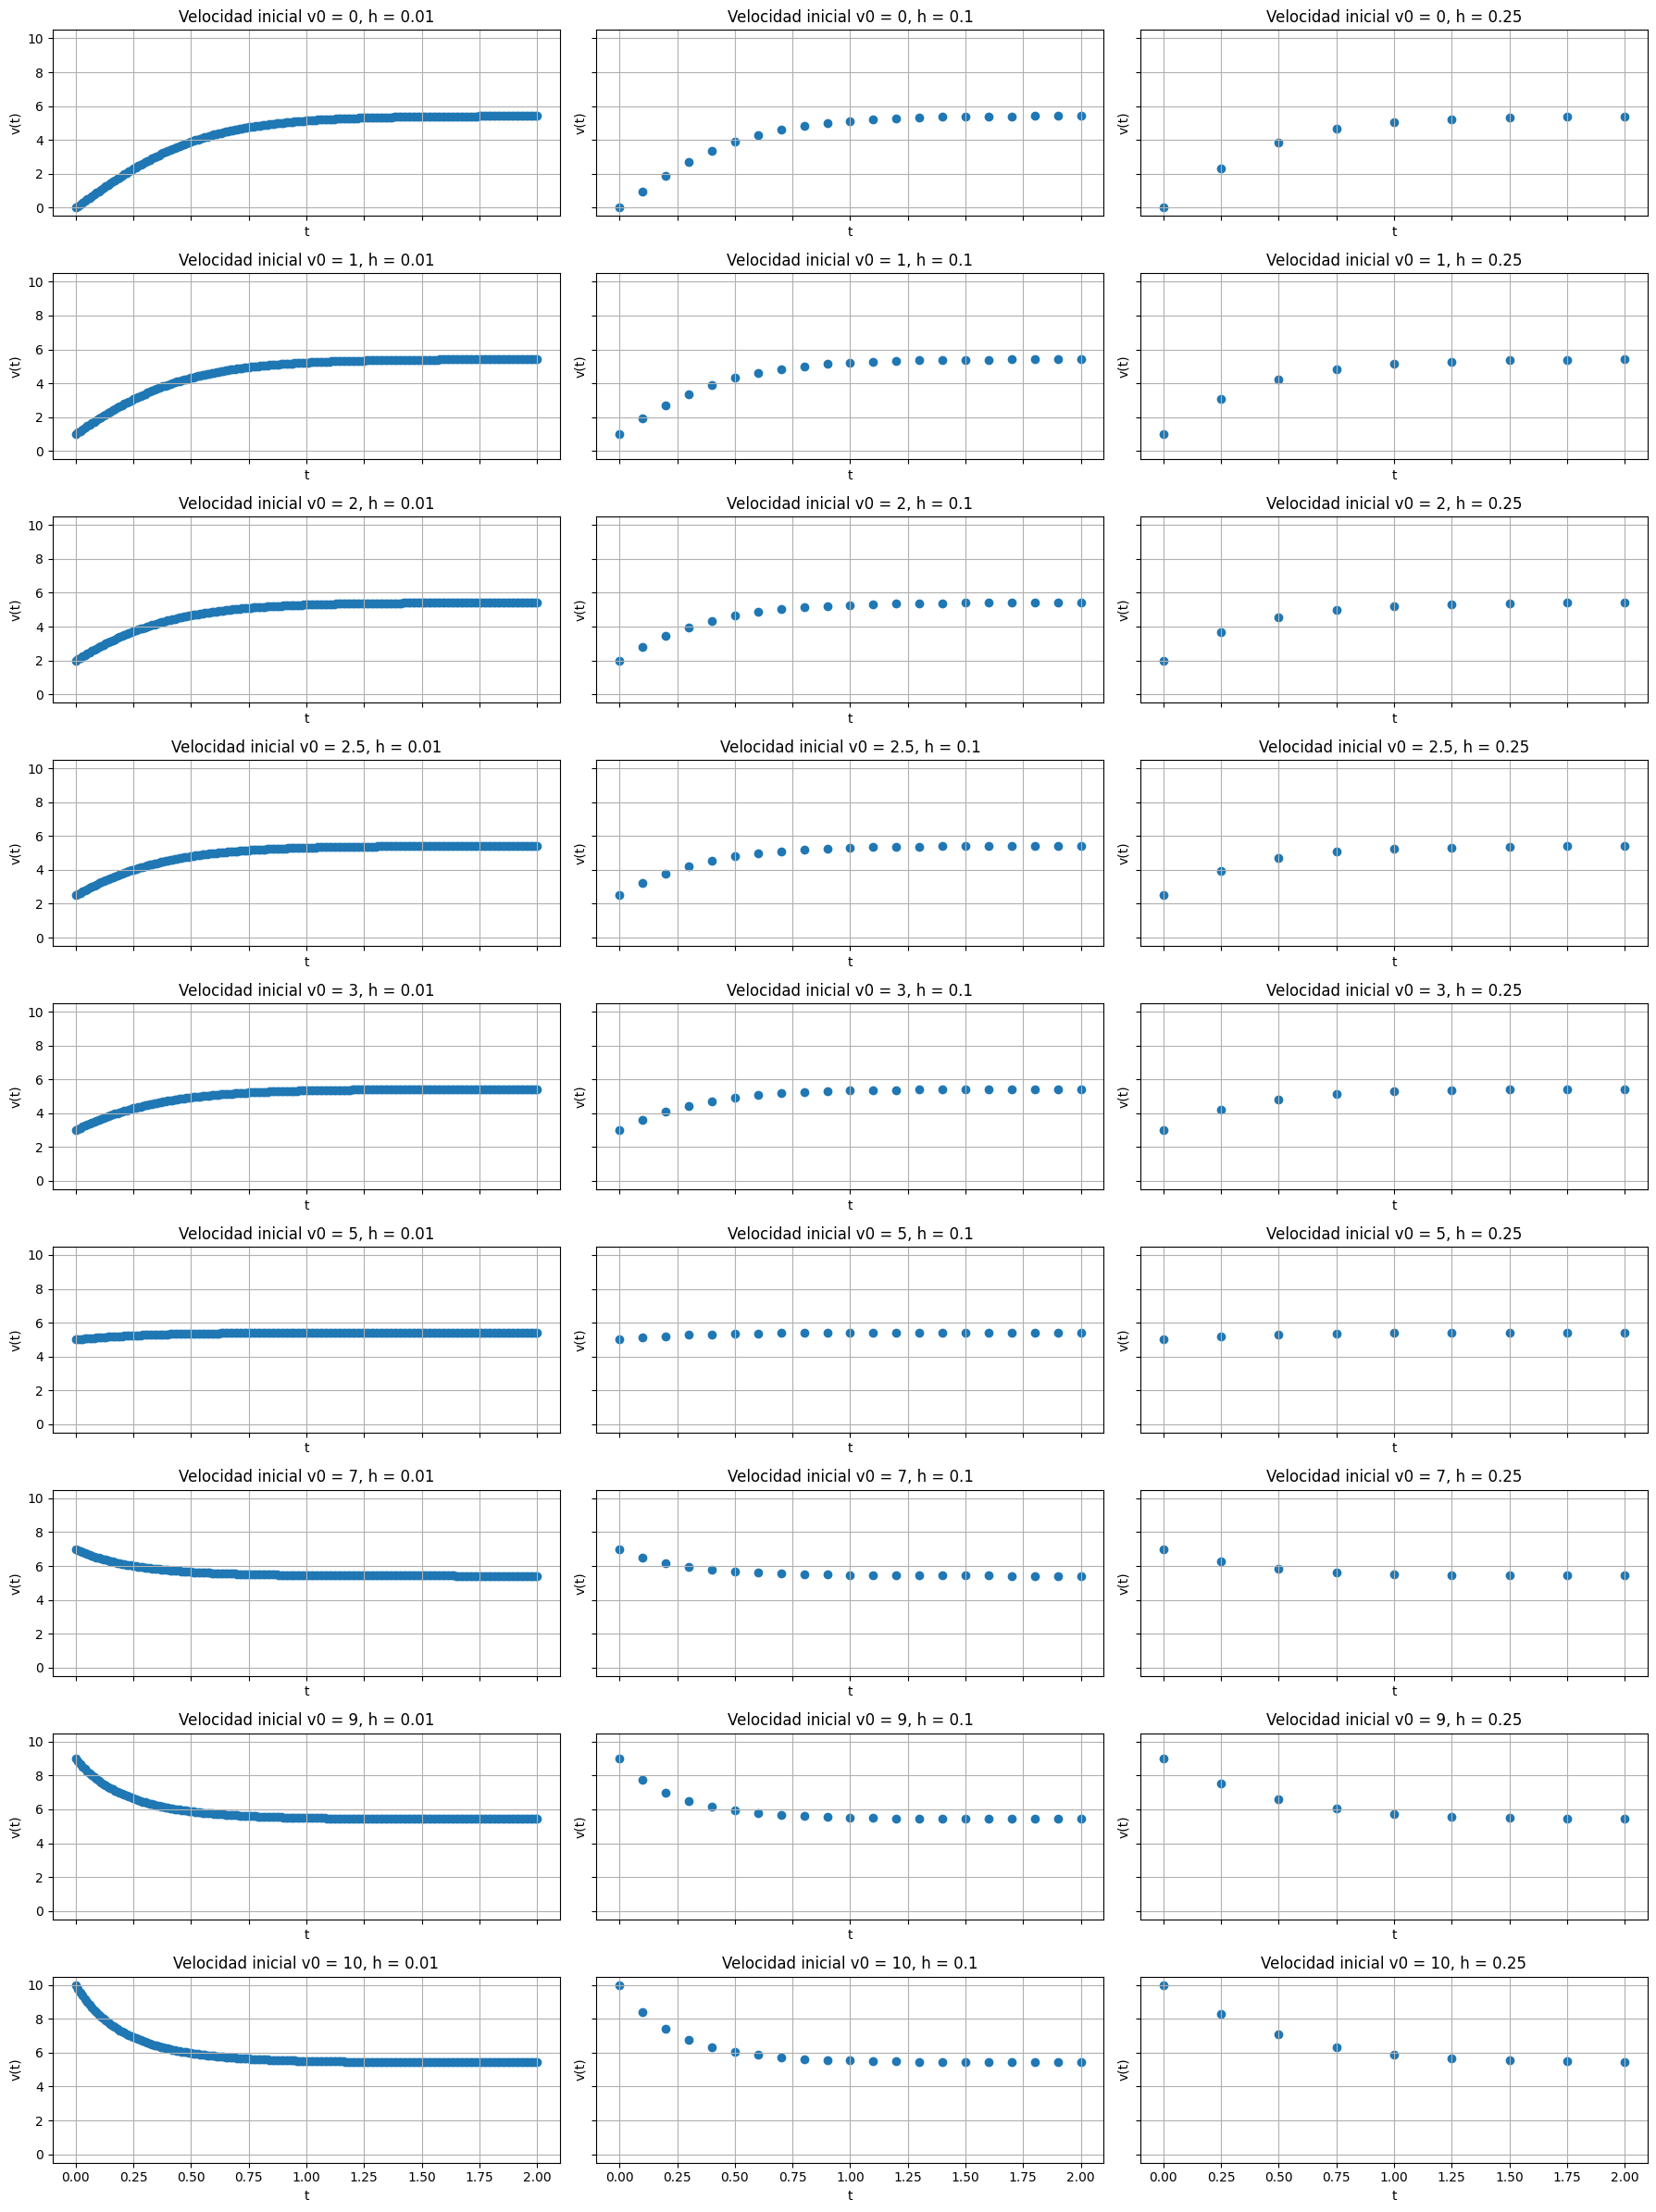

In [16]:
# Ejercicio 5

# g: aceleración gravitatoria       (g = 9.81)
# c_r: coeficiente de rozamiento    (c_r = 0.028)
# m : masa                          (m = 0.084)

# Ecuación:  v = g - (c_r/m) * v**2

def runge_kutta2(g, cr, m, t0, tf, v0, h):
    def f(t, v):
        return g - (cr / m) * v**2
    
    t_valores = [t0]
    v_valores = [v0]

    t_actual = t0
    v_actual = v0

    while t_actual < tf:
        v_actual = v_actual + h * f(t_actual + h/2, v_actual + h/2 * f(t_actual, v_actual))
        t_actual = t_actual + h

        t_valores.append(t_actual)
        v_valores.append(v_actual)

    return np.array(t_valores), np.array(v_valores)

hs = [0.01, 0.1, 0.25]
velocidades_iniciales = [0, 1, 2, 2.5, 3, 5, 7, 9, 10]

fig, ax = plt.subplots(ncols=len(hs), nrows=len(velocidades_iniciales), figsize=(18, 24), sharex=True, sharey=True)

for i, h in enumerate(hs):
    for j, v0 in enumerate(velocidades_iniciales):
        tiempos, velocidades = runge_kutta2(g = 9.81, cr = 0.028, m = 0.084, t0 = 0, tf = 2, v0 = v0, h = h)
        ax[j, i].scatter(tiempos, velocidades)
        ax[j, i].grid(True)
        ax[j, i].set_xlabel("t")
        ax[j, i].set_ylabel("v(t)")
        ax[j, i].set_title(f"Velocidad inicial v0 = {v0}, h = {h}")


plt.tight_layout()
plt.show()

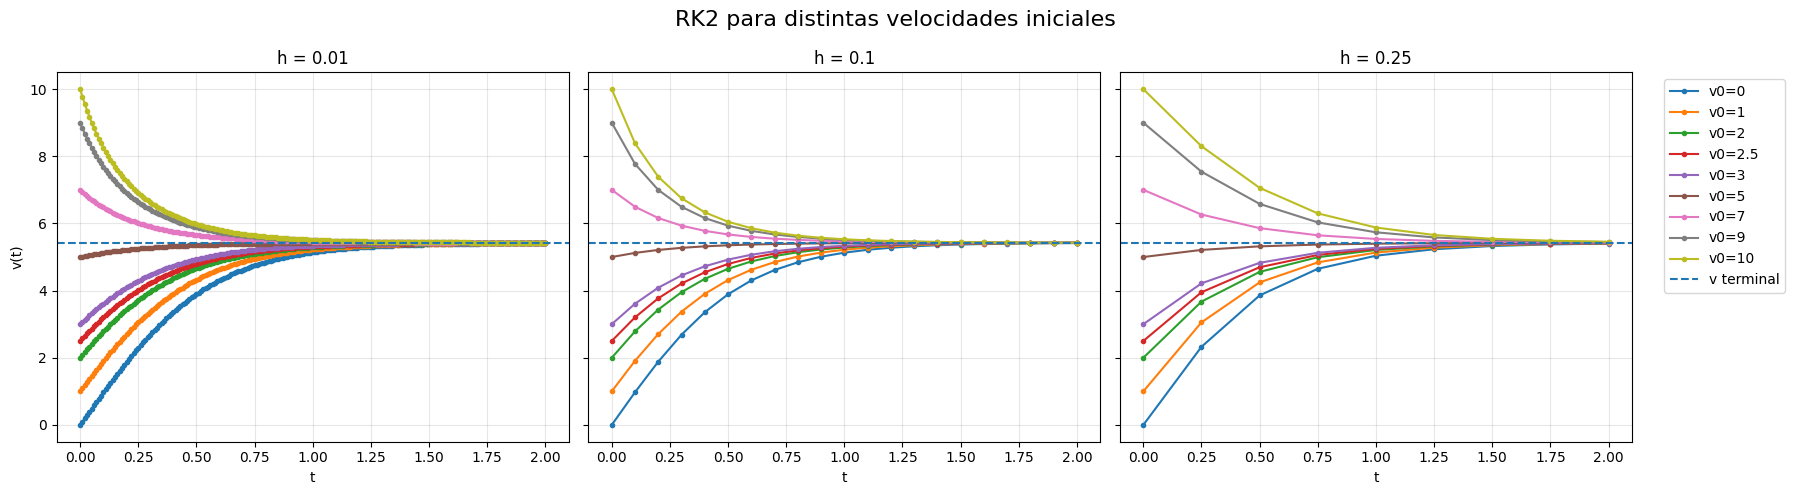

In [17]:
g = 9.81
cr = 0.028
m = 0.084

def runge_kutta2(g, cr, m, t0, tf, v0, h):
    def f(t, v):
        return g - (cr / m) * v**2
    
    t_valores = [t0]
    v_valores = [v0]

    t_actual = t0
    v_actual = v0

    while t_actual < tf:
        k1 = f(t_actual, v_actual)
        k2 = f(t_actual + h/2, v_actual + h/2 * k1)

        v_actual = v_actual + h * k2
        t_actual = t_actual + h

        t_valores.append(t_actual)
        v_valores.append(v_actual)

    return np.array(t_valores), np.array(v_valores)

hs = [0.01, 0.1, 0.25]
velocidades_iniciales = [0, 1, 2, 2.5, 3, 5, 7, 9, 10]
v_terminal = np.sqrt(m * g / cr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, h in enumerate(hs):
    for v0 in velocidades_iniciales:
        tiempos, velocidades = runge_kutta2(g, cr, m, 0, 2, v0, h)
        axes[i].plot(tiempos, velocidades, marker='o', markersize=3, label=f"v0={v0}")

    axes[i].axhline(v_terminal, linestyle='--', label='v terminal')
    axes[i].set_title(f"h = {h}")
    axes[i].set_xlabel("t")
    axes[i].grid(True, alpha=0.3)

axes[0].set_ylabel("v(t)")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle("RK2 para distintas velocidades iniciales", fontsize=16)
plt.tight_layout()
plt.show()